In [580]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

In [581]:
file_name = "Car_Price.csv"

In [582]:
car_data = pd.read_csv(file_name)
df = pd.DataFrame(car_data)

In [583]:
df.shape

(205, 26)

In [584]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [585]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [586]:
df['CarCompany'] = df['CarName'].apply(lambda row: row.split(" ")[0])

In [587]:
df['CarCompany'].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

In [588]:
correct_names = {
    "alfa-romero": "alfa-romeo",
    "audi": "audi",
    "bmw": "bmw",
    "chevrolet": "chevrolet",
    "dodge": "dodge",
    "honda": "honda",
    "isuzu": "isuzu",
    "jaguar": "jaguar",
    "maxda": "mazda",
    "mazda": "mazda",
    "buick": "buick",
    "mercury": "mercury",
    "mitsubishi": "mitsubishi",
    "Nissan": "nissan",
    "nissan": "nissan",
    "peugeot": "peugeot",
    "plymouth": "plymouth",
    "porsche": "porsche",
    "porcshce": "porsche",
    "renault": "renault",
    "saab": "saab",
    "subaru": "subaru",
    "toyota": "toyota",
    "toyouta": "toyota",
    "vokswagen": "volkswagen",
    "volkswagen": "volkswagen",
    "vw": "volkswagen",
    "volvo": "volvo"
}
df['CarCompany'] = df['CarCompany'].replace(correct_names)
df['CarCompany'].unique()

array(['alfa-romeo', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'mazda', 'buick', 'mercury', 'mitsubishi',
       'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab',
       'subaru', 'toyota', 'volkswagen', 'volvo'], dtype=object)

In [589]:
figsize = (19, 11)

In [590]:
def get_color():
  hex = "0123456789ABCDEF"
  color = ""
  counter = 0
  while counter < 2:
    color += random.choice(hex)
    counter += 1
  return color

In [591]:
def render_boxplot(data, labels, xlabel, ylabel,
                   figsize=(6, 4), widths=None):
  plt.figure(figsize=figsize)
  bplot = plt.boxplot(data, patch_artist=True,
           tick_labels=labels, widths=widths)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  for patch in bplot['boxes']:
    red = get_color()
    green = get_color()
    blue = get_color()
    patch.set_facecolor("#" + red + green + blue)
  plt.show()

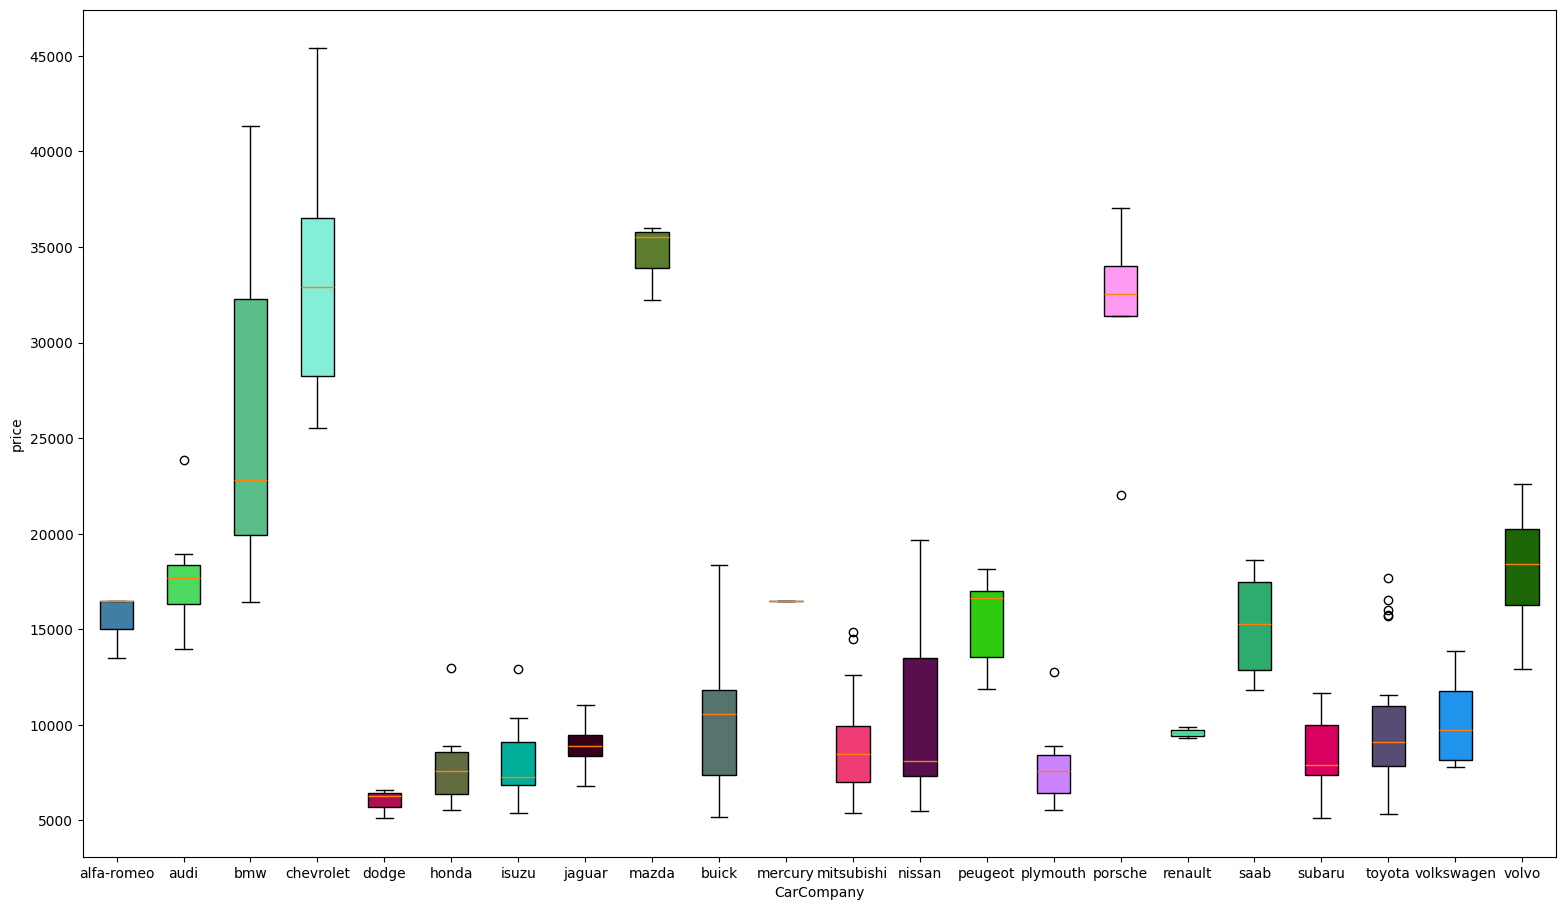

In [592]:
data = df.groupby("CarCompany")['price'].apply(list)
labels = df['CarCompany'].unique()
render_boxplot(data=data, labels=labels, xlabel="CarCompany", ylabel="price", figsize=figsize)

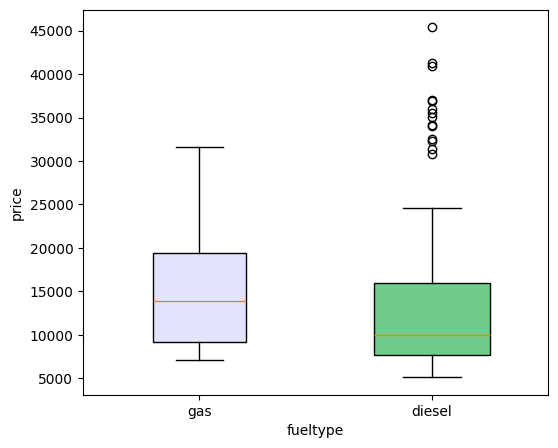

In [593]:
data = df.groupby("fueltype")['price'].apply(list)
labels = df['fueltype'].unique()
render_boxplot(data, labels, "fueltype", "price", figsize=(6, 5), widths=(0.4, 0.5))

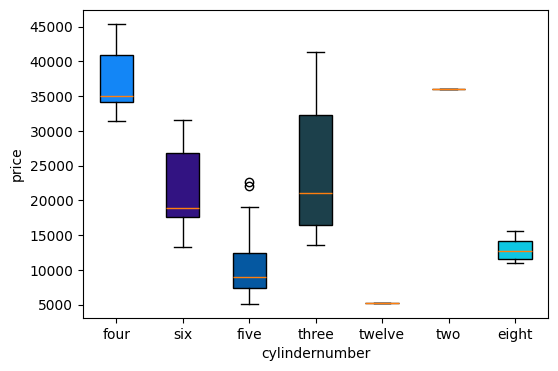

In [594]:
data = df.groupby("cylindernumber")['price'].apply(list)
labels = df['cylindernumber'].unique()
render_boxplot(data, labels, "cylindernumber", "price")

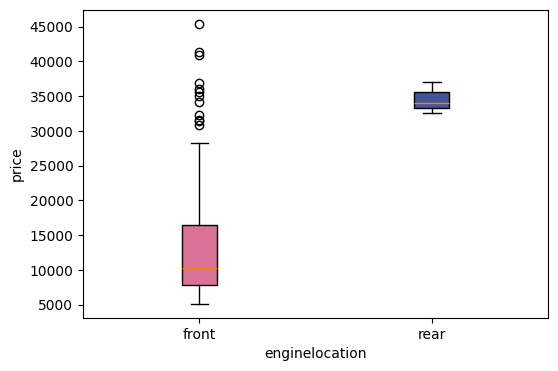

In [595]:
data = df.groupby("enginelocation")['price'].apply(list)
labels = df['enginelocation'].unique()
render_boxplot(data, labels, "enginelocation", "price")

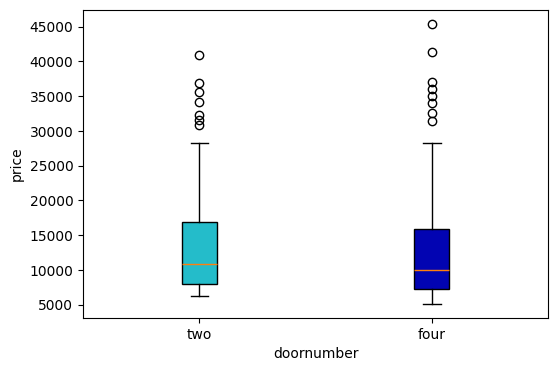

In [596]:
data = df.groupby("doornumber")['price'].apply(list)
labels = df['doornumber'].unique()
render_boxplot(data, labels, "doornumber", "price")

In [597]:
group = df.groupby("CarCompany")
company_price = {name:price.median() for (name, price) in group['price']}
company_price

{'alfa-romeo': 16500.0,
 'audi': 17710.0,
 'bmw': 22835.0,
 'buick': 32892.0,
 'chevrolet': 6295.0,
 'dodge': 7609.0,
 'honda': 7295.0,
 'isuzu': 8916.5,
 'jaguar': 35550.0,
 'mazda': 10595.0,
 'mercury': 16503.0,
 'mitsubishi': 8499.0,
 'nissan': 8124.0,
 'peugeot': 16630.0,
 'plymouth': 7609.0,
 'porsche': 32528.0,
 'renault': 9595.0,
 'saab': 15275.0,
 'subaru': 7894.0,
 'toyota': 9103.0,
 'volkswagen': 9737.5,
 'volvo': 18420.0}

In [598]:
# df['CarCompany'] = pd.cut(df['price'],
#            bins=[df['price'].min(), 10000, 20000, df['price'].max()],
#            labels=["med", "high", "low"])
# df.CarCompany.unique()


In [599]:
car_data_train, car_data_test = train_test_split(df)
car_data_train.shape
# car_data_test.shape

(153, 27)